# 05 - Demo: simulated conveyor belt

This notebook shows the system running **without a real belt**. The idea:

1. We take images from the **test** split (the model never saw them during training).
2. We slide them from left to right over a belt, one after another, as if they passed in front of a fixed camera.
3. We run the recommended model (**YOLOv8s + `proposed`**) on every frame and draw what it detects.
4. We measure the time per frame and which classes it detects.

The physical separation mechanism (robotic arm or compressed air) is left as future work: here we focus on **which objects would have to be separated and which category they belong to**.

In [1]:
import random
import shutil
import subprocess
import time
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from IPython.display import Video, display
from ultralytics import YOLO

# Repo root (the notebook can be opened from notebooks/ or from the root)
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()

# --- Configuration ---------------------------------------------------------
TEST_IMAGES = ROOT / "data/processed/images/test"
WEIGHTS = ROOT / "reports/runs/yolov8s_proposed/weights/best.pt"
OUT_DIR = ROOT / "reports/demo"

SECONDS = 20      # video length (s)
FPS = 30
WIDTH, HEIGHT = 1280, 540
TILE = 420        # side of each image on the belt (px)
GAP = 140         # gap between images (px)
SPEED = 7.0       # belt speed (px per frame)
CONF = 0.25       # confidence threshold
SEED = 42

if torch.cuda.is_available():
    DEVICE = "cuda"
elif torch.backends.mps.is_available():
    DEVICE = "mps"
else:
    DEVICE = "cpu"
print("Root:", ROOT, "| device:", DEVICE)

if not TEST_IMAGES.exists():
    raise SystemExit(
        f"{TEST_IMAGES} does not exist. Download the dataset (v2, YOLOv8) into data/raw/ "
        "and run `uv run python scripts/process_data.py` (see README)."
    )
OUT_DIR.mkdir(parents=True, exist_ok=True)

Root: /Users/bamazon/vision_computadora/VPC2_TP | device: mps


## 1. Build the simulated belt

Each test image is resized to a square and placed on a belt background. On every frame all of them move `SPEED` pixels to the right.

11 test images | 600 frames


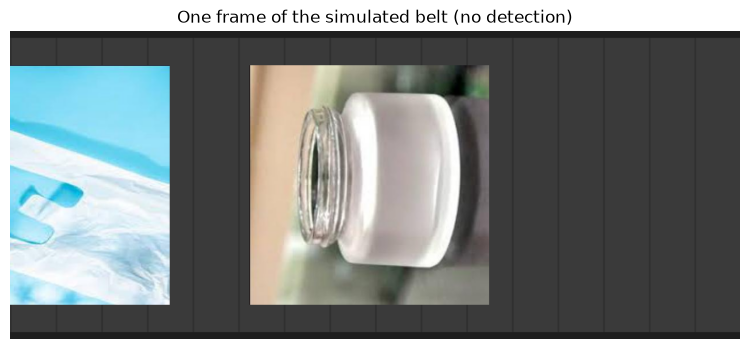

In [2]:
def load_tiles(images_dir, count, tile, seed):
    paths = sorted(p for p in images_dir.iterdir() if p.suffix.lower() in {".jpg", ".jpeg", ".png"})
    random.Random(seed).shuffle(paths)
    tiles = []
    for path in paths[:count]:
        img = cv2.imread(str(path))
        if img is not None:
            tiles.append(cv2.resize(img, (tile, tile), interpolation=cv2.INTER_AREA))
    return tiles


def belt_background(width, height):
    bg = np.full((height, width, 3), 58, dtype=np.uint8)
    for x in range(0, width, 80):
        bg[:, x : x + 3] = 48
    bg[:12, :] = 30
    bg[-12:, :] = 30
    return bg


def belt_frame(background, tiles, frame_idx):
    frame = background.copy()
    period = TILE + GAP
    y0 = (HEIGHT - TILE) // 2
    offset = frame_idx * SPEED
    for i, tile in enumerate(tiles):
        x = int(offset - (i + 1) * period + GAP)
        if x >= WIDTH or x + TILE <= 0:
            continue
        xs, xe = max(x, 0), min(x + TILE, WIDTH)
        frame[y0 : y0 + TILE, xs:xe] = tile[:, xs - x : xe - x]
    return frame


frames_total = int(SECONDS * FPS)
needed = int((frames_total * SPEED + WIDTH) / (TILE + GAP)) + 2
tiles = load_tiles(TEST_IMAGES, needed, TILE, SEED)
background = belt_background(WIDTH, HEIGHT)
print(f"{len(tiles)} test images | {frames_total} frames")

plt.figure(figsize=(10, 4))
plt.imshow(cv2.cvtColor(belt_frame(background, tiles, 120), cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.title("One frame of the simulated belt (no detection)")
plt.show()

## 2. Run the model on every frame

We process frame by frame, as an online system would: detect, draw and record the inference time.

In [3]:
model = YOLO(str(WEIGHTS))
names = model.names

raw_path = OUT_DIR / "cinta_simulada_raw.mp4"
writer = cv2.VideoWriter(str(raw_path), cv2.VideoWriter_fourcc(*"mp4v"), FPS, (WIDTH, HEIGHT))

records = []          # one row per detection
frame_ms = []         # inference time per frame
sample_frames = {}    # a few annotated frames for the paper figure
margin = min(60, frames_total // 4)
sample_idx = set(np.linspace(margin, frames_total - 1 - margin, 6, dtype=int))

for idx in range(frames_total):
    frame = belt_frame(background, tiles, idx)
    t0 = time.perf_counter()
    result = model.predict(frame, imgsz=640, conf=CONF, device=DEVICE, verbose=False)[0]
    frame_ms.append((time.perf_counter() - t0) * 1000)

    for cls, conf in zip(result.boxes.cls.tolist(), result.boxes.conf.tolist()):
        records.append({"frame": idx, "class": names[int(cls)], "conf": conf})

    annotated = result.plot()
    writer.write(annotated)
    if idx in sample_idx:
        sample_frames[idx] = annotated

writer.release()
print(f"Raw video: {raw_path}")

Raw video: /Users/bamazon/vision_computadora/VPC2_TP/reports/demo/cinta_simulada_raw.mp4


## 3. See the result

The video is re-encoded to H.264 so it plays in the notebook and in any player.

In [4]:
final_path = OUT_DIR / "cinta_simulada_detecciones.mp4"
if shutil.which("ffmpeg"):
    subprocess.run(
        ["ffmpeg", "-y", "-loglevel", "error", "-i", str(raw_path),
         "-c:v", "libx264", "-pix_fmt", "yuv420p", str(final_path)],
        check=True,
    )
else:
    shutil.copy(raw_path, final_path)
    print("ffmpeg not found: using the raw video (mp4v).")

print("Final video:", final_path)
display(Video(str(final_path), embed=False, width=900))

ffmpeg not found: using the raw video (mp4v).
Final video: /Users/bamazon/vision_computadora/VPC2_TP/reports/demo/cinta_simulada_detecciones.mp4


## 4. Demo metrics

Latency includes preprocessing, inference and NMS for each frame. Detections are counted **per frame**: the same object appears in many consecutive frames, so this shows the class distribution, not how many distinct objects went by (that would require *tracking*, which is future work).

In [5]:
frame_ms = np.array(frame_ms)
print(f"Mean latency per frame: {frame_ms.mean():.1f} ms ({1000 / frame_ms.mean():.1f} FPS) on {DEVICE}")
print(f"p95: {np.percentile(frame_ms, 95):.1f} ms")

df = pd.DataFrame(records)
if df.empty:
    print("No detections: try a lower CONF.")
else:
    resumen = (
        df.groupby("class")
        .agg(detections=("conf", "size"), mean_conf=("conf", "mean"))
        .sort_values("detections", ascending=False)
    )
    resumen["mean_conf"] = resumen["mean_conf"].round(3)
    display(resumen)
    resumen.to_csv(OUT_DIR / "demo_resumen_detecciones.csv")

Mean latency per frame: 16.5 ms (60.5 FPS) on mps
p95: 15.8 ms


,detections,mean_conf
class,,
GLASS,1241,0.616
METAL,746,0.617
PLASTIC,482,0.487
PAPER,188,0.686
BIODEGRADABLE,53,0.554
CARDBOARD,5,0.396


## 5. Figure for the paper

Six frames of the demo with the detections drawn.

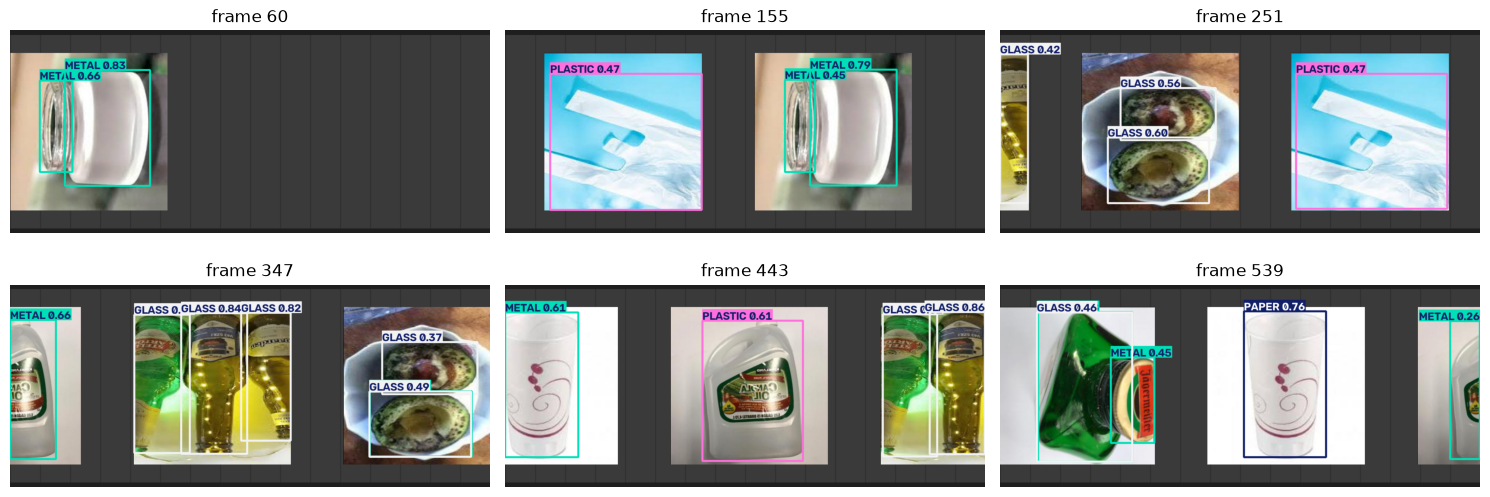

Figure saved to /Users/bamazon/vision_computadora/VPC2_TP/reports/demo/demo_frames.png


In [6]:
fig, axes = plt.subplots(2, 3, figsize=(15, 5.5))
for ax, (idx, img) in zip(axes.ravel(), sorted(sample_frames.items())):
    ax.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    ax.set_title(f"frame {idx}")
    ax.axis("off")
plt.tight_layout()
fig_path = OUT_DIR / "demo_frames.png"
fig.savefig(fig_path, dpi=200, bbox_inches="tight")
plt.show()
print("Figure saved to", fig_path)